# TP3 - Carga y Descarga de un Capacitor

**Materia:** Electricidad y Magnetismo

**Integrantes:**
* Fernanda Perez
* Tomas Aragusuku
* Jonathan Gomez
* Carla Rocca

## Objetivo
Antes de la instancia de medición, la cátedra nos pidió una **muestra teórica** del comportamiento de carga y descarga de un capacitor de $C = 2\mu F$ en serie con una resistencia de $R = 160\Omega$.

El objetivo de este notebook es:
1. Calcular la constante de tiempo $\tau = R.C$ del circuito.
2. Graficar la tensión $V_C(t)$ y la corriente $I(t)$ esperadas durante $5\tau$ de carga y $5\tau$ de descarga (es decir, un período $T = 10\tau$), repitiendo el ciclo para verificar la periodicidad.
3. Usar estos resultados teóricos para elegir la frecuencia del generador de funciones y la escala de tiempo del osciloscopio en la instancia de medición real, y como referencia para comparar contra los datos experimentales que se incorporarán más adelante.

## Introducción teórica

Un capacitor conectado en serie con una resistencia forma un circuito **RC**. Si se lo alimenta con una tensión $V_0$ (por ejemplo, la salida de un generador de funciones en modo onda cuadrada), el capacitor se **carga** mientras la fuente está conectada y se **descarga** a través de la resistencia cuando la fuente se cortocircuita o se desconecta.

**Carga:**
$$V_C(t) = V_0\left(1 - e^{-t/\tau}\right) \qquad I(t) = \frac{V_0}{R}\,e^{-t/\tau}$$

**Descarga:**
$$V_C(t) = V_0\,e^{-t/\tau} \qquad I(t) = -\frac{V_0}{R}\,e^{-t/\tau}$$

donde $\tau = R.C$ es la **constante de tiempo** del circuito. El signo negativo en la corriente de descarga indica que circula en sentido opuesto al de la carga, aunque su módulo responde a la misma exponencial.

Una propiedad útil de la exponencial es que en $t = 5\tau$ el capacitor ya alcanzó más del **99,3%** de su valor final ($1 - e^{-5} \approx 0,993$). Por eso, si se arma una señal cuadrada de período $T = 10\tau$ (5$\tau$ de nivel alto + 5$\tau$ de nivel bajo), el capacitor alcanza a completar prácticamente toda la carga y toda la descarga dentro de cada semiperíodo, y el patrón se repite de forma periódica en el osciloscopio.

## Elección de los parámetros

$R = 160\,\Omega$ y $C = 2\,\mu F$ son los valores del circuito. La tensión $V_0$ quedaba a elección del grupo; elegimos **$V_0 = 5V$** porque:

* Es un valor estándar de fuente/generador de laboratorio, fácil de fijar con precisión.
* Da una corriente inicial de carga y una tensión final cómodas de leer tanto en el osciloscopio como en el multímetro.
* Conviene revisar la potencia que va a disipar la resistencia en el peor caso (capacitor descargado, $t=0$), para elegir una $R$ de potencia nominal adecuada. Esto se calcula en la siguiente celda.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Parámetros del circuito (R y C del circuito, V0 elegido por el grupo)
R = 160        # Resistencia [ohm]
C = 2e-6       # Capacidad [F]
V0 = 5         # Tensión de la fuente [V]

tau = R * C            # Constante de tiempo RC
t_fase = 5 * tau       # Duración de cada fase (carga o descarga) -> ~99.3% del valor final
T = 2 * t_fase         # Período completo de un ciclo carga+descarga (= 10*tau)

print(f"tau        = {tau*1e3:.3f} ms")
print(f"5*tau      = {t_fase*1e3:.3f} ms")
print(f"T = 10*tau = {T*1e3:.3f} ms")
print(f"f = 1/T    = {1/T:.1f} Hz  (frecuencia sugerida para el generador de funciones)")


tau        = 0.320 ms
5*tau      = 1.600 ms
T = 10*tau = 3.200 ms
f = 1/T    = 312.5 Hz  (frecuencia sugerida para el generador de funciones)


In [3]:
# Corriente y potencia en el instante más exigente (t=0 de la carga, capacitor descargado)
I0 = V0 / R
P0 = V0**2 / R

print(f"I0 (t=0, carga) = {I0*1e3:.2f} mA")
print(f"P0 (t=0, carga) = {P0*1e3:.1f} mW")


I0 (t=0, carga) = 31.25 mA
P0 (t=0, carga) = 156.2 mW


Con $V_0 = 5V$, la corriente inicial es de aproximadamente **31,25 mA** y la potencia disipada en la resistencia en ese instante es de **~156 mW**. Una resistencia común de $1/4W$ (250 mW) alcanza, aunque trabajaría al ~62% de su potencia nominal; para tener más margen conviene usar una $R$ de $160\Omega$ de $1/2W$.

## Construcción de las curvas teóricas

Armamos las curvas de $V_C(t)$ e $I(t)$ concatenando fases de carga y descarga de duración $5\tau$ cada una, repitiendo el ciclo dos veces para verificar la periodicidad.

In [4]:
n_ciclos = 2     # cantidad de ciclos carga+descarga a graficar
n_puntos = 300   # puntos por fase (resolución de la curva)

t_list, v_list, i_list = [], [], []
t_acumulado = 0.0

for ciclo in range(n_ciclos):
    # --- Fase de carga ---
    t = np.linspace(0, t_fase, n_puntos)
    v = V0 * (1 - np.exp(-t / tau))
    i = (V0 / R) * np.exp(-t / tau)

    t_list.append(t + t_acumulado)
    v_list.append(v)
    i_list.append(i)
    t_acumulado += t_fase

    # --- Fase de descarga ---
    t = np.linspace(0, t_fase, n_puntos)
    v = V0 * np.exp(-t / tau)
    i = -(V0 / R) * np.exp(-t / tau)   # mismo módulo, sentido opuesto a la carga

    t_list.append(t + t_acumulado)
    v_list.append(v)
    i_list.append(i)
    t_acumulado += t_fase

t_total = np.concatenate(t_list)
v_total = np.concatenate(v_list)
i_total = np.concatenate(i_list)


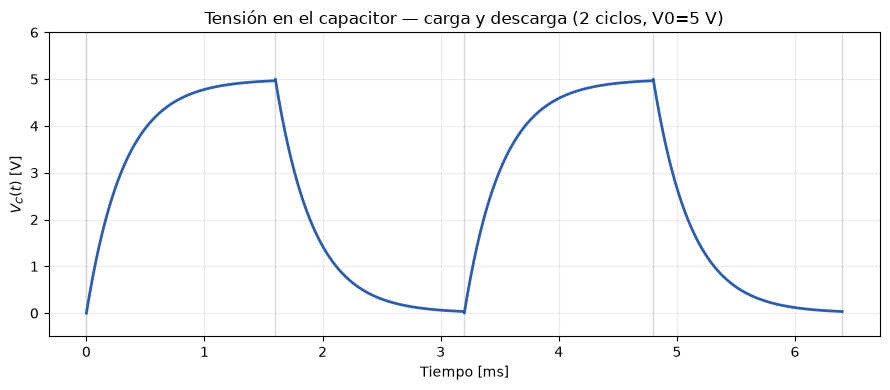

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_total * 1e3, v_total, color="#2E5EAA", linewidth=2)

for k in range(2 * n_ciclos + 1):
    ax.axvline(k * t_fase * 1e3, color="0.85", linewidth=1, zorder=0)

ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel(r"$V_C(t)$ [V]")
ax.set_title(f"Tensión en el capacitor \u2014 carga y descarga ({n_ciclos} ciclos, V0={V0} V)")
ax.grid(alpha=0.25)
ax.set_ylim(-0.5, V0 + 1)
fig.tight_layout()
plt.show()


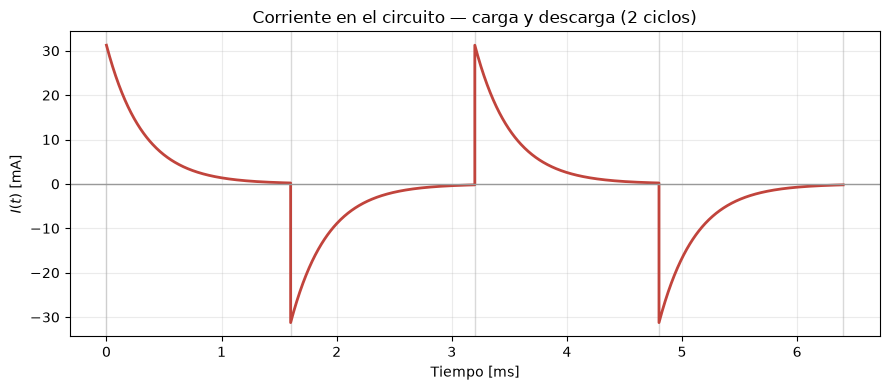

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_total * 1e3, i_total * 1e3, color="#C1443C", linewidth=2)
ax.axhline(0, color="0.6", linewidth=1)

for k in range(2 * n_ciclos + 1):
    ax.axvline(k * t_fase * 1e3, color="0.85", linewidth=1, zorder=0)

ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel(r"$I(t)$ [mA]")
ax.set_title(f"Corriente en el circuito \u2014 carga y descarga ({n_ciclos} ciclos)")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Análisis

* En cada tramo de $5\tau$ la tensión $V_C(t)$ llega prácticamente a $V_0$ (carga) o a $0V$ (descarga), lo que confirma que un período $T = 10\tau$ alcanza para observar el ciclo completo sin cortarlo.
* La corriente $I(t)$ tiene la misma forma exponencial en ambas fases, pero cambia de signo entre carga y descarga porque el sentido de circulación se invierte.
* Con $\tau \approx 0,32\,ms$, el fenómeno completo dura unos pocos milisegundos: **no se puede seguir a ojo con un cronómetro**, por lo que la medición real va a requerir un generador de funciones en $\approx 312,5\,Hz$ (onda cuadrada) y un osciloscopio con una base de tiempo de pocos $ms/div$.

## Próximos pasos

Esta muestra teórica sirve como referencia para configurar el generador de funciones y el osciloscopio en la instancia de medición. Una vez tomados los datos experimentales, se agregarán a este notebook para compararlos contra las curvas calculadas acá (valor de $\tau$ medido vs. teórico, forma de las curvas, etc.).